## Figure 6 — $\tilde\lambda_2$, $\tilde\lambda_N$, $\tilde\lambda_2/\tilde\lambda_N$ over $\{\mathcal T^{(2)},\mathcal I^{(1,2)}\}$
---

Simplest non-trivial case $M=2$ (pairs + triangles), $N=100$, $k^{(1)}=6$, $k^{(2)}=3$. We sweep the plane $(\mathcal T^{(2)},\mathcal I^{(1,2)})\in[0,1]^2$, averaging each cell over `n_ensemble` structures, and plot the mean $\tilde\lambda_2$ (a), $\tilde\lambda_N$ (b), ratio (c). $\sigma^{(m)}=1/k^{(m)}$.

**Synthetic model (Appendix A of the paper).** To reach a target $\mathcal T^{(2)}$ we start from a max-intra-overlap triangle set and rewire it down; to reach a target $\mathcal I^{(1,2)}$ we build the pairwise layer from the triangle faces (max inter overlap) then rewire it down. The repo's rewiring routines (`Hyperedge Overlap`, `Structure generation`) implement this but hard-import numba. `util.py` ports a numba-optional generator that spans the plane approximately.

> **Uncertainty flagged:** getting *exactly* a prescribed $(\mathcal T^{(2)},\mathcal I^{(1,2)})$ pair needs the iterative minimizer run to a target value. Here I use a lightweight interpolating generator (mix of blocked and random hyperedges) that lands *near* each target; the code prints the mean achieved overlaps per grid line. For a publication-exact match you'd run the repo's `minimizing_intra_order_overlap` / `minimizing_inter_order_overlap` to each target — tell me if you want that (needs numba, slower).


In [1]:
import sys, os, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.insert(0, os.getcwd())
import util
sys.path.insert(0, util.OVERLAP_DIR)
from hyperedge_overlap_utils import (intra_order_hyperedge_overlap as intra_overlap,
                                      inter_order_hyperedge_overlap as inter_overlap)
out_dir = Path(util.REPO_ROOT) / 'outputs' / 'fig6'
out_dir.mkdir(parents=True, exist_ok=True)
rng_seed = 1

In [2]:
def structure_at_overlap(N, k1, k2, target_T2, target_I12, seed=0):
    '''Approximate generator spanning (T2, I12) in [0,1]^2 for M=2.

    Strategy:
      * Triangles: interpolate between clustered blocks (T2~1) and random
        regular (T2~0) by assigning a fraction ~target_T2 of nodes to blocks.
      * Pairs: a fraction ~target_I12 of the required triangle-faces are added
        as links (raising inter-order overlap); the remaining links are random
        to keep k1 regular-ish.
    Returns pairs, triangles.
    '''
    rng = np.random.default_rng(seed)
    # ---- triangles: blend blocked and random ----
    # blocks of size 4 give k2 = C(3,2) = 3
    Bsz = util.block_size_for_degrees({2: k2})   # k2=3 -> B=4
    n_block_nodes = int(round(target_T2 * N))
    n_block_nodes -= n_block_nodes % Bsz         # multiple of block size
    tri_list = []
    if n_block_nodes >= Bsz:
        blk, _ = util.clustered_blocks(n_block_nodes, Bsz, orders=[2], seed=seed)
        tri_list.append(blk[2])
    # remaining nodes get random-regular triangles
    rem = np.arange(n_block_nodes, N)
    if len(rem) >= 3:
        rt, _ = util.random_regular_mbody(len(rem), k2, 2, seed=seed+1)
        tri_list.append(rt + n_block_nodes)
    triangles = np.vstack([t for t in tri_list if len(t)]) if tri_list else \
                util.random_regular_mbody(N, k2, 2, seed=seed)[0]
    # ---- pairs: mix triangle-faces (inter overlap) with random links ----
    faces = set()
    for a,b,c in triangles:
        faces.add(tuple(sorted((a,b)))); faces.add(tuple(sorted((a,c)))); faces.add(tuple(sorted((b,c))))
    faces = list(faces); rng.shuffle(faces)
    n_face_links = int(round(target_I12 * len(faces)))
    chosen = set(faces[:n_face_links])
    # top up with random links to approx k1-regular
    deg = np.zeros(N,int)
    pairs = set(chosen)
    for a,b in chosen: deg[a]+=1; deg[b]+=1
    target_links = k1*N//2
    tries=0
    while len(pairs) < target_links and tries < 200000:
        tries+=1
        i,j = rng.integers(0,N,2)
        if i==j: continue
        e=tuple(sorted((int(i),int(j))))
        if e in pairs: continue
        pairs.add(e); deg[i]+=1; deg[j]+=1
    return np.array(sorted(pairs),dtype=np.int64), triangles

# quick single-point sanity
p,t = structure_at_overlap(100,6,3,0.5,0.5,seed=0)
print("sanity:", intra_overlap(t,2)[0], inter_overlap(p,1,t,2))

sanity: 0.5 0.5111111111111111


In [ ]:
# DO NOT RUN
# --- Fig 6 sweep ---
GRID6      = 10      # grid resolution per axis (start small; 11 for paper-like)
N_ENSEMBLE = 100      # structures averaged per cell (paper uses 100; start small)
N, k1, k2  = 100, 6, 3

T2_axis  = np.linspace(0, 1, GRID6)
I12_axis = np.linspace(0, 1, GRID6)
lam2  = np.zeros((GRID6, GRID6))   # rows = I12, cols = T2  (match paper axes)
lamN  = np.zeros((GRID6, GRID6))
t0=time.time()
for ii, I12 in enumerate(I12_axis):
    for jj, T2 in enumerate(T2_axis):
        v2=[]; vN=[]
        for s in range(N_ENSEMBLE):
            p,t = structure_at_overlap(N,k1,k2,T2,I12,seed=1000*ii+10*jj+s)
            eig,_,_,_ = util.effective_laplacian_spectrum([p,t],[1,2],[1/k1,1/k2], N=N)
            v2.append(eig[1]); vN.append(eig[-1])
        lam2[ii,jj]=np.mean(v2); lamN[ii,jj]=np.mean(vN)
    print(f"  I12 row {ii+1}/{GRID6} done")
ratio = lam2/lamN
print("sweep done in %.1fs"%(time.time()-t0))

# save
np.save(out_dir / 'fig6-a.npy', lam2)
np.save(out_dir / 'fig6-b.npy', lamN)
np.save(out_dir / 'fig6-c.npy', ratio)

  I12 row 1/10 done
  I12 row 2/10 done
  I12 row 3/10 done
  I12 row 4/10 done
  I12 row 5/10 done
  I12 row 6/10 done
  I12 row 7/10 done
  I12 row 8/10 done
  I12 row 9/10 done
  I12 row 10/10 done
sweep done in 1288.9s


In [3]:
GRID6      = 10
N_ENSEMBLE = 100

T2_axis  = np.linspace(0, 1, GRID6)
I12_axis = np.linspace(0, 1, GRID6)

lam2 = np.load(out_dir / 'fig6-a.npy')
lamN = np.load(out_dir / 'fig6-b.npy')
ratio = np.load(out_dir / 'fig6-c.npy')

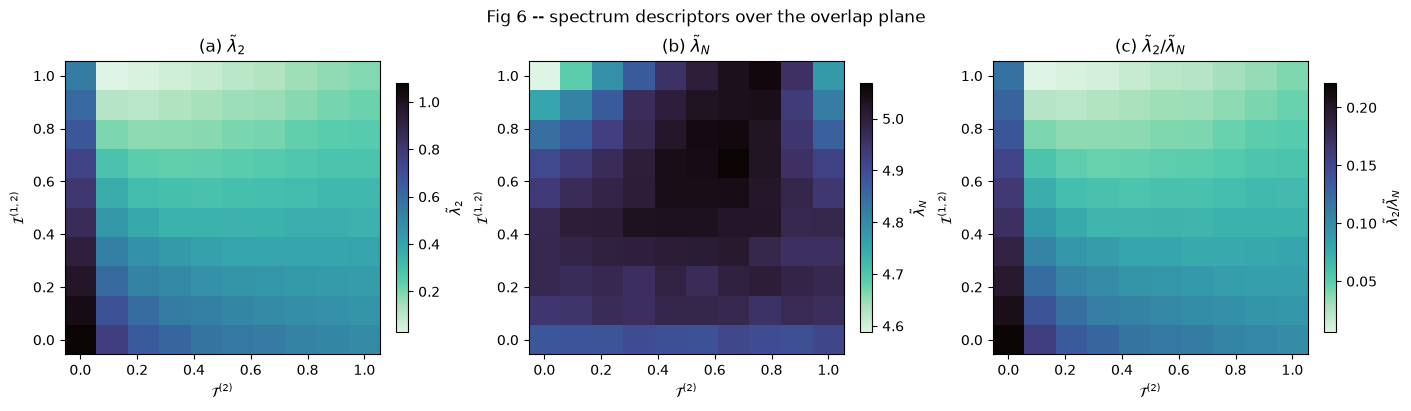

In [4]:
fig, axes = plt.subplots(1,3, figsize=(14,4), constrained_layout=True)
cmap = "mako_r"
for ax, Z, ttl, lab in zip(axes, [lam2, lamN, ratio],
        ["(a) $\\tilde\\lambda_2$","(b) $\\tilde\\lambda_N$","(c) $\\tilde\\lambda_2/\\tilde\\lambda_N$"],
        [r"$\tilde\lambda_2$",r"$\tilde\lambda_N$",r"$\tilde\lambda_2/\tilde\lambda_N$"]):
    im=ax.pcolormesh(T2_axis, I12_axis, Z, shading="auto", cmap=cmap)
    ax.set_xlabel(r"$\mathcal{T}^{(2)}$")
    ax.set_ylabel(r"$\mathcal{I}^{(1,2)}$")
    ax.set_title(ttl)
    fig.colorbar(im, ax=ax, shrink=0.85, label=lab)
fig.suptitle("Fig 6 -- spectrum descriptors over the overlap plane")
plt.show()

fig.savefig("figures/Fig6.png", dpi=300, bbox_inches="tight")